# Multi-Subject Progressive Attention Prediction Model

This notebook implements progressive learning across 50 subjects using regression to predict attention scores.

**Features:**
- Downloads subjects from URL list
- Progressive learning with memory retention (150 samples per subject)
- Regression model: predicts 1-5 scores, converts to 0-100%
- Automatic cleanup after each subject

**Output Format:**
- Raw scores: 1.0-5.0 (1 = attentive, 5 = inattentive)
- Percentage: 0-100% (Linear: 1→100%, 5→0%)

In [1]:
# Import Required Libraries
import os
import json
import numpy as np
import pandas as pd
import subprocess
import shutil
import pickle
from datetime import datetime
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler

!pip install keras-tuner -q
import keras_tuner as kt

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU Available: []


## Configuration

In [2]:
# Training Configuration
TRAINING_CONFIG = {
    # Data settings
    'download_links_file': '7856c716c0cc4589a23ee4a23d8a0893.txt',
    'num_subjects': 50,
    'memory_samples_per_subject': 150,
    'memory_weight': 0.2,

    # Training parameters
    'initial_lr': 0.001,
    'finetune_lr': 0.00005,
    'initial_epochs': 100,
    'finetune_epochs': 50,
    'batch_size': 32,
    'test_size': 0.2,
    'random_state': 42,

    # Optimization callbacks
    'early_stopping_patience': 10,
    'reduce_lr_patience': 5,
    'reduce_lr_factor': 0.5,
    'min_learning_rate': 1e-7,

    # Hyperparameter Tuning
    'enable_tuning': True,
    'tuning_trials': 20,
    'tuning_epochs': 30,
    'tuning_subject_index': 0,  # Use first subject for tuning

    # Cross-Validation
    'enable_cv': True,
    'cv_folds': 5,
    'cv_subject_index': 0,  # Use first subject for CV

    # Features - base features + derived features for discriminative power
    'feature_cols': ['face_area', 'body_area', 'pitch', 'yaw', 'roll', 'pose_vis_mean',
                     'face_detected', 'face_body_ratio', 'head_movement', 'abs_yaw', 'abs_pitch'],

    # Model architecture (will be updated by hyperparameter tuning)
    'units_layer_1': 128,
    'units_layer_2': 64,
    'units_layer_3': 32,
    'dropout_1': 0.3,
    'dropout_2': 0.3,
    'dropout_3': 0.2,
    'l2_regularization': 0.01,
    'batch_normalization': True,
}

# Set random seeds
tf.random.set_seed(TRAINING_CONFIG['random_state'])
np.random.seed(TRAINING_CONFIG['random_state'])

print("Configuration:")
for key, value in TRAINING_CONFIG.items():
    print(f"  {key:.<35} {value}")

Configuration:
  download_links_file................ 7856c716c0cc4589a23ee4a23d8a0893.txt
  num_subjects....................... 50
  memory_samples_per_subject......... 150
  memory_weight...................... 0.2
  initial_lr......................... 0.001
  finetune_lr........................ 5e-05
  initial_epochs..................... 100
  finetune_epochs.................... 50
  batch_size......................... 32
  test_size.......................... 0.2
  random_state....................... 42
  early_stopping_patience............ 10
  reduce_lr_patience................. 5
  reduce_lr_factor................... 0.5
  min_learning_rate.................. 1e-07
  enable_tuning...................... True
  tuning_trials...................... 20
  tuning_epochs...................... 30
  tuning_subject_index............... 0
  enable_cv.......................... True
  cv_folds........................... 5
  cv_subject_index................... 0
  feature_cols.....................

## Load Download Links

In [3]:
import urllib.parse

def extract_subject_info(line):
    """Extract subject name and URL from download link line."""
    url = line.strip()
    if not url:
        return None

    # Parse the URL to get query parameters
    parsed_url = urllib.parse.urlparse(url)
    query_params = urllib.parse.parse_qs(parsed_url.query)

    file_name_list = query_params.get('fileName')
    if file_name_list:
        file_name = file_name_list[0]
        # Remove .zip extension if present
        subject_name = file_name.replace('.zip', '')
        return {'name': subject_name, 'url': url}
    return None

# Load download links
with open(TRAINING_CONFIG['download_links_file'], 'r') as f:
    lines = f.readlines()

all_subjects = [extract_subject_info(line) for line in lines if line.strip()]
all_subjects = [s for s in all_subjects if s is not None]

# Filter out 'context_cam' subjects
filtered_subjects = [s for s in all_subjects if 'context_cam' not in s['name']]

print(f"Total subjects available (before filtering): {len(all_subjects)}")
print(f"Total 'subject_xx' subjects available: {len(filtered_subjects)}")

# Select subjects
# Reorder to put subject_07 first (it has all 5 classes)
subject_07 = next((s for s in filtered_subjects if s['name'] == 'subject_07'), None)
other_subjects = [s for s in filtered_subjects if s['name'] != 'subject_07']

if subject_07:
    TRAINING_SUBJECTS = [subject_07] + other_subjects[:TRAINING_CONFIG['num_subjects']-1]
else:
    TRAINING_SUBJECTS = filtered_subjects[:TRAINING_CONFIG['num_subjects']]

print(f"\nSelected {len(TRAINING_SUBJECTS)} subjects for training")
print(f"First subject: {TRAINING_SUBJECTS[0]['name']}")
print(f"Last subject: {TRAINING_SUBJECTS[-1]['name']}")

Total subjects available (before filtering): 618
Total 'subject_xx' subjects available: 483

Selected 50 subjects for training
First subject: subject_07
Last subject: subject_03


## Download and Cleanup Functions

In [4]:
def download_and_extract_subject_from_url(subject_info):
    """
    Download and extract a subject using wget.

    Args:
        subject_info: Dict with 'name' and 'url' keys

    Returns:
        True if successful, False otherwise
    """
    subject_name = subject_info['name']
    url = subject_info['url']
    zip_file = f"{subject_name}.zip"

    print(f"\n{'='*60}")
    print(f"Downloading {subject_name}...")
    print(f"{'='*60}")

    try:
        # Download using wget
        print(f"⬇ Downloading from URL...")
        result = subprocess.run(
            ['wget', '-q', '--show-progress', '-O', zip_file, url],
            capture_output=False,
            text=True
        )

        if result.returncode != 0:
            print(f"❌ Download failed")
            return False

        # Create subject directory for extraction
        os.makedirs(subject_name, exist_ok=True)

        # Extract into the subject directory
        print(f"📦 Extracting to {subject_name}/...")
        result = subprocess.run(
            ['unzip', '-q', '-o', zip_file, '-d', subject_name],
            capture_output=True,
            text=True
        )

        if result.returncode != 0:
            print(f"❌ Extraction failed")
            # Clean up the created directory if extraction fails
            shutil.rmtree(subject_name, ignore_errors=True)
            return False

        # Verify extraction (check for expected subdirectories inside subject_name)
        if not (os.path.exists(os.path.join(subject_name, 'images')) or \
                os.path.exists(os.path.join(subject_name, 'labels'))):
            print(f"❌ Expected subdirectories (images/labels) not found in {subject_name} after extraction")
            return False

        print(f"✅ Download and extraction complete")
        return True

    except Exception as e:
        print(f"❌ Error: {e}")
        return False

def cleanup_subject_files(subject_name):
    """Remove subject directory and zip file."""
    print(f"\n🗑 Cleaning up {subject_name}...")

    # Remove zip file
    zip_file = f"{subject_name}.zip"
    if os.path.exists(zip_file):
        os.remove(zip_file)
        print(f"  ✓ Removed {zip_file}")

    # Remove subject directory
    if os.path.exists(subject_name):
        shutil.rmtree(subject_name)
        print(f"  ✓ Removed {subject_name}/ directory")

    print(f"✅ Cleanup complete")

print("Download and cleanup functions loaded")

Download and cleanup functions loaded


## Data Processing Functions

In [5]:
import logging
import traceback as tb

# Configure logging for the notebook
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    datefmt='%H:%M:%S'
)
logger = logging.getLogger('AttentionModel')
logger.setLevel(logging.DEBUG)

def parse_timestamp(dt_str):
    """Parse mixed timestamp formats used by label files."""
    s = str(dt_str).strip()

    # Common full datetime formats
    for fmt in ("%Y-%m-%d %H:%M:%S.%f", "%Y-%m-%d %H:%M:%S"):
        try:
            return pd.to_datetime(s, format=fmt)
        except Exception:
            pass

    # Time-only formats found in some subjects
    for fmt in ("%H:%M:%S:%f", "%H:%M:%S.%f", "%H:%M:%S"):
        try:
            return pd.to_datetime(s, format=fmt)
        except Exception:
            pass

    # Last fallback for uncommon variants
    ts = pd.to_datetime(s, format='mixed', errors='coerce')
    if pd.isna(ts):
        return pd.NaT
    return ts

def load_label_file(path, source_name):
    """Load a single label JSON file."""
    if not os.path.exists(path):
        logger.warning(f"Label file not found: {path}")
        return pd.DataFrame()

    with open(path, 'r') as f:
        data = json.load(f)

    df = pd.DataFrame(data)
    df['source'] = source_name
    logger.info(f"  Loaded {len(df)} labels from {source_name}")
    return df

def extract_metadata_features(metadata):
    """Extract numerical features from metadata.

    Handles the actual JSON structure:
      { "person": {
            "face": {
                "bounding_box": {"x0":..,"y0":..,"x1":..,"y1":..},
                "headpose": {"pose": {"pitch":..,"yaw":..,"roll":..}},
                ...
            },
            "body": {
                "bounding_box": {"x0":..,"y0":..,"x1":..,"y1":..},
                "body_pose": [ {"landmark":..,"visibility":..}, ... ],
                ...
            }
        }
      }
    """
    # ── Unwrap "person" wrapper if present ──
    person = metadata.get('person', metadata)

    # ── Face bounding-box → face_area ──
    face = person.get('face', {}) or {}
    face_bb = face.get('bounding_box', {})
    if face_bb and all(k in face_bb for k in ('x0', 'y0', 'x1', 'y1')):
        face_area = abs(face_bb['x1'] - face_bb['x0']) * abs(face_bb['y1'] - face_bb['y0'])
    else:
        face_area = np.nan

    # ── Body bounding-box → body_area ──
    body = person.get('body', {})
    body_bb = body.get('bounding_box', {})
    if body_bb and all(k in body_bb for k in ('x0', 'y0', 'x1', 'y1')):
        body_area = abs(body_bb['x1'] - body_bb['x0']) * abs(body_bb['y1'] - body_bb['y0'])
    else:
        body_area = np.nan

    # ── Head pose angles ──
    headpose = face.get('headpose', {})
    pose = headpose.get('pose', {}) or {}
    pitch = pose.get('pitch', np.nan)
    yaw   = pose.get('yaw',   np.nan)
    roll  = pose.get('roll',  np.nan)

    # ── Body keypoints visibility ──
    keypoints = body.get('body_pose', [])
    if keypoints:
        visibilities = [kp.get('visibility', 0) for kp in keypoints if isinstance(kp, dict)]
        pose_vis_mean = np.mean(visibilities) if visibilities else np.nan
    else:
        pose_vis_mean = np.nan

    feats = {
        'face_area': face_area,
        'body_area': body_area,
        'pitch': pitch,
        'yaw': yaw,
        'roll': roll,
        'pose_vis_mean': pose_vis_mean,
        'face_detected': 0.0 if (np.isnan(face_area) if isinstance(face_area, float) else False) or (face_area is None) or (isinstance(face_area, (int, float)) and face_area <= 0) else 1.0,
    }

    # Log if ALL features are NaN (indicates metadata parsing issue)
    non_nan_count = sum(1 for k, v in feats.items() if k != 'face_detected' and not (isinstance(v, float) and np.isnan(v)))
    if non_nan_count == 0:
        logger.debug(f"  All features are NaN. Metadata keys present: {list(metadata.keys())}")
        if 'person' in metadata:
            logger.debug(f"    person sub-keys: {list(metadata['person'].keys())}")

    return feats

def add_derived_features(df):
    """Compute derived features for better attention prediction."""
    # Binary face detection indicator (crucial for no-face vs face-detected distinction)
    if 'face_detected' not in df.columns:
        df['face_detected'] = ((df['face_area'].notna()) & (df['face_area'] > 0)).astype(float)

    # Face-to-body area ratio (normalized face prominence)
    df['face_body_ratio'] = np.where(
        (df['face_area'].notna()) & (df['body_area'].notna()) & (df['body_area'] > 0),
        df['face_area'].fillna(0) / df['body_area'],
        0.0
    )

    # Head movement magnitude (Euclidean norm of head pose angles)
    pitch_vals = df['pitch'].fillna(0.0)
    yaw_vals = df['yaw'].fillna(0.0)
    roll_vals = df['roll'].fillna(0.0)
    df['head_movement'] = np.sqrt(pitch_vals**2 + yaw_vals**2 + roll_vals**2)
    df.loc[df['face_detected'] == 0.0, 'head_movement'] = 0.0

    # Absolute yaw and pitch (measures of looking away from center)
    df['abs_yaw'] = df['yaw'].fillna(0.0).abs()
    df['abs_pitch'] = df['pitch'].fillna(0.0).abs()
    df.loc[df['face_detected'] == 0.0, 'abs_yaw'] = 0.0
    df.loc[df['face_detected'] == 0.0, 'abs_pitch'] = 0.0

    return df

# ---------- Counters for metadata error tracking ----------
_metadata_stats = {'found': 0, 'missing': 0, 'read_error': 0, 'all_nan': 0}

def process_single_image(row_data):
    """Process a single image: locate metadata file, extract features."""
    image_path, t_sec, attention, emotion = row_data

    # ──────────────────────────────────────────────────────────
    # FIX: Normalise path separators so the replace works on
    # both Windows (backslash) and Linux/macOS (forward slash).
    # ──────────────────────────────────────────────────────────
    normalised = image_path.replace("\\", "/")                      # unify to forward slashes
    metadata_path = normalised.replace("/images/", "/metadata/")    # swap directory

    # Handle both .jpg and .png extensions → .json
    for ext in (".jpg", ".jpeg", ".png"):
        if metadata_path.lower().endswith(ext):
            metadata_path = metadata_path[: -len(ext)] + ".json"
            break

    # Convert back to OS-native path
    metadata_path = os.path.normpath(metadata_path)

    try:
        if not os.path.exists(metadata_path):
            _metadata_stats['missing'] += 1
            if _metadata_stats['missing'] <= 3:  # Only log first 3 to avoid spam
                logger.warning(f"  Metadata file NOT FOUND: {metadata_path}")
                logger.warning(f"    (derived from image: {image_path})")
            return {
                "image_path": image_path, "t_sec": t_sec,
                "attention": attention, "emotion_label": emotion,
                "face_area": np.nan, "body_area": np.nan, "pitch": np.nan,
                "yaw": np.nan, "roll": np.nan, "pose_vis_mean": np.nan,
                "face_detected": 0.0,
            }

        _metadata_stats['found'] += 1
        with open(metadata_path, 'r') as f:
            metadata = json.load(f)

        feats = extract_metadata_features(metadata)

        # Check if we got at least one real (non-NaN) feature
        real_vals = [v for k, v in feats.items()
                     if k != 'face_detected' and isinstance(v, (int, float)) and not np.isnan(v)]
        if len(real_vals) == 0:
            _metadata_stats['all_nan'] += 1

        feats["image_path"] = image_path
        feats["t_sec"] = t_sec
        feats["attention"] = attention
        feats["emotion_label"] = emotion
        return feats

    except json.JSONDecodeError as e:
        _metadata_stats['read_error'] += 1
        logger.error(f"  JSON decode error for {metadata_path}: {e}")
        return {
            "image_path": image_path, "t_sec": t_sec,
            "attention": attention, "emotion_label": emotion,
            "face_area": np.nan, "body_area": np.nan, "pitch": np.nan,
            "yaw": np.nan, "roll": np.nan, "pose_vis_mean": np.nan,
            "face_detected": 0.0,
        }
    except Exception as e:
        _metadata_stats['read_error'] += 1
        logger.error(f"  Unexpected error processing metadata for {image_path}: {e}")
        logger.debug(tb.format_exc())
        return {
            "image_path": image_path, "t_sec": t_sec,
            "attention": attention, "emotion_label": emotion,
            "face_area": np.nan, "body_area": np.nan, "pitch": np.nan,
            "yaw": np.nan, "roll": np.nan, "pose_vis_mean": np.nan,
            "face_detected": 0.0,
        }

def process_subject_data(subject_name):
    """
    Process subject data: load labels, extract features.

    Returns:
        df_feat: DataFrame with features
        y_scores: Array of attention scores (1-5 range)
    """
    global _metadata_stats
    _metadata_stats = {'found': 0, 'missing': 0, 'read_error': 0, 'all_nan': 0}

    # Handle nested directory structure (ZIP might extract to subject_name/subject_name/)
    if os.path.exists(os.path.join(subject_name, subject_name, 'images')):
        subject_dir = os.path.join(subject_name, subject_name)
        print(f"\nProcessing {subject_name}... (nested structure detected)")
    elif os.path.exists(os.path.join(subject_name, 'images')):
        subject_dir = subject_name
        print(f"\nProcessing {subject_name}...")
    else:
        raise ValueError(f"Could not find images directory for {subject_name}")

    # ── Log directory structure for debugging ──
    logger.info(f"  Subject dir: {os.path.abspath(subject_dir)}")
    images_dir = os.path.join(subject_dir, 'images')
    metadata_dir = os.path.join(subject_dir, 'metadata')
    labels_dir = os.path.join(subject_dir, 'labels')
    logger.info(f"  images/  exists: {os.path.isdir(images_dir)}  ({len(os.listdir(images_dir)) if os.path.isdir(images_dir) else 0} files)")
    logger.info(f"  metadata/ exists: {os.path.isdir(metadata_dir)}  ({len(os.listdir(metadata_dir)) if os.path.isdir(metadata_dir) else 0} files)")
    logger.info(f"  labels/  exists: {os.path.isdir(labels_dir)}  ({len(os.listdir(labels_dir)) if os.path.isdir(labels_dir) else 0} files)")

    # Show sample metadata file to help debug path issues
    if os.path.isdir(metadata_dir):
        sample_meta = os.listdir(metadata_dir)[:3]
        logger.info(f"  Sample metadata files: {sample_meta}")

    # Load labels
    label_files = {
        "labeler_01": f"{subject_dir}/labels/labeler_01.json",
        "labeler_02": f"{subject_dir}/labels/labeler_02.json",
        "labeler_03": f"{subject_dir}/labels/labeler_03.json",
        "labeler_04": f"{subject_dir}/labels/labeler_04.json",
        "self": f"{subject_dir}/labels/self_labeling.json",
    }

    dfs = [load_label_file(path, src) for src, path in label_files.items()]
    labels_raw = pd.concat([df for df in dfs if not df.empty], ignore_index=True)
    print(f"  ✓ Labels: {len(labels_raw)} entries")

    # Convert attention and emotion to numeric (they may be loaded as strings)
    labels_raw["attention"] = pd.to_numeric(labels_raw["attention"], errors='coerce')
    labels_raw["emotion"] = pd.to_numeric(labels_raw["emotion"], errors='coerce')

    # Parse timestamps
    labels_raw["time"] = labels_raw["datetime"].apply(parse_timestamp)
    invalid_time_rows = labels_raw["time"].isna().sum()
    if invalid_time_rows:
        print(f"  ⚠ Dropping {invalid_time_rows} labels with invalid datetime format")
        labels_raw = labels_raw.dropna(subset=["time"]).copy()

    if labels_raw.empty:
        raise ValueError("No valid label timestamps found after parsing")

    t0 = labels_raw["time"].min()
    labels_raw["t_sec"] = (labels_raw["time"] - t0).dt.total_seconds()

    # Merge expert and self labels
    expert = labels_raw[labels_raw["source"].str.contains("labeler")]
    expert_grouped = expert.groupby("t_sec").agg({"attention": "mean", "emotion": "mean"}).reset_index()

    self_df = labels_raw[labels_raw["source"] == "self"][["t_sec", "attention", "emotion"]]
    labels_final = pd.merge(expert_grouped, self_df, on="t_sec", how="outer", suffixes=("_expert", "_self"))

    labels_final["attention"] = labels_final["attention_expert"].combine_first(labels_final["attention_self"])
    labels_final["emotion"] = labels_final["emotion_expert"].combine_first(labels_final["emotion_self"])
    labels_final = labels_final[["t_sec", "attention", "emotion"]].sort_values("t_sec").reset_index(drop=True)

    # Load images (try both .png and .jpg extensions)
    img_dir = Path(f"{subject_dir}/images")
    img_files = sorted(img_dir.glob("*.png"))

    if not img_files:
        # Try .jpg if no .png found
        img_files = sorted(img_dir.glob("*.jpg"))

    if not img_files:
        raise ValueError(f"No image files (.png or .jpg) found in {img_dir}")

    print(f"  ✓ Found {len(img_files)} images")

    # Parse image timestamps - try multiple formats
    timestamps = []
    successful_parses = 0

    for img_file in img_files:
        ts = None
        filename = img_file.stem  # Remove extension

        # Strategy 1: Time format with underscores (e.g., 10_40_43_047895.png)
        # Format: HH_MM_SS_microseconds
        if filename.count("_") == 3:
            try:
                parts = filename.split("_")
                h, m, s, us = parts[0], parts[1], parts[2], parts[3]
                ts = datetime.strptime(f"{h}:{m}:{s}.{us}", "%H:%M:%S.%f")
                successful_parses += 1
            except:
                pass

        # Strategy 2: Timestamp at end after underscore (e.g., frame_20210315123045678901)
        if ts is None:
            ts_str = filename.split("_")[-1]
            for fmt in ("%Y%m%d%H%M%S%f", "%Y%m%d%H%M%S"):
                try:
                    ts = datetime.strptime(ts_str, fmt)
                    successful_parses += 1
                    break
                except:
                    pass

        # Strategy 3: Entire filename is timestamp
        if ts is None:
            for fmt in ("%Y%m%d%H%M%S%f", "%Y%m%d%H%M%S"):
                try:
                    ts = datetime.strptime(filename, fmt)
                    successful_parses += 1
                    break
                except:
                    pass

        # Strategy 4: Extract any numeric sequence that looks like a timestamp
        if ts is None:
            import re
            # Look for 14+ digit sequences (YYYYMMDDHHMMSS or longer)
            matches = re.findall(r'\d{14,}', filename)
            if matches:
                for match in matches:
                    for fmt in ("%Y%m%d%H%M%S%f", "%Y%m%d%H%M%S"):
                        try:
                            ts = datetime.strptime(match[:len(fmt.replace('%f', '000000'))], fmt)
                            successful_parses += 1
                            break
                        except:
                            pass
                    if ts:
                        break

        timestamps.append(ts)

    print(f"  ✓ Parsed {successful_parses}/{len(img_files)} timestamps")

    if successful_parses == 0:
        # Show sample filenames for debugging
        print(f"  ⚠ Sample filenames:")
        for i, f in enumerate(img_files[:5]):
            print(f"    - {f.name}")
        raise ValueError(f"Could not parse any image timestamps. Check filename format above.")

    df_images = pd.DataFrame({
        "image_path": [str(f) for f in img_files],
        "timestamp": timestamps
    })
    df_images = df_images.dropna(subset=["timestamp"])

    if df_images.empty:
        raise ValueError(f"No valid image timestamps after filtering (parsed {successful_parses} but all were None)")

    # Ensure timestamp column is datetime dtype
    df_images["timestamp"] = pd.to_datetime(df_images["timestamp"])
    df_images["t_sec"] = (df_images["timestamp"] - df_images["timestamp"].min()).dt.total_seconds()
    print(f"  ✓ Valid images with timestamps: {len(df_images)}")

    # ── Log a sample image path so we can verify metadata path derivation ──
    if len(df_images) > 0:
        sample_img = df_images.iloc[0]["image_path"]
        sample_norm = sample_img.replace("\\", "/")
        sample_meta = sample_norm.replace("/images/", "/metadata/")
        for ext in (".jpg", ".jpeg", ".png"):
            if sample_meta.lower().endswith(ext):
                sample_meta = sample_meta[:-len(ext)] + ".json"
                break
        sample_meta = os.path.normpath(sample_meta)
        logger.info(f"  Sample image path:    {sample_img}")
        logger.info(f"  Derived metadata path: {sample_meta}")
        logger.info(f"  Metadata file exists?  {os.path.exists(sample_meta)}")

    # Assign labels to images
    def find_nearest_label(t):
        idx = (labels_final["t_sec"] - t).abs().idxmin()
        return labels_final.loc[idx, "attention"], labels_final.loc[idx, "emotion"]

    df_images[["attention", "emotion"]] = df_images["t_sec"].apply(
        lambda t: pd.Series(find_nearest_label(t))
    )
    df_images = df_images.dropna(subset=["attention"])

    # Extract features from metadata
    row_data = list(zip(df_images["image_path"], df_images["t_sec"],
                        df_images["attention"], df_images["emotion"]))

    rows = []
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = {executor.submit(process_single_image, rd): rd for rd in row_data}
        for future in tqdm(as_completed(futures), total=len(futures), desc="  Extracting features", leave=False):
            rows.append(future.result())

    # ── Report metadata extraction statistics ──
    total_images = len(row_data)
    print(f"\n  📊 METADATA EXTRACTION REPORT:")
    print(f"     Total images processed:   {total_images}")
    print(f"     Metadata files found:     {_metadata_stats['found']}  ({_metadata_stats['found']/max(total_images,1)*100:.1f}%)")
    print(f"     Metadata files MISSING:   {_metadata_stats['missing']}  ({_metadata_stats['missing']/max(total_images,1)*100:.1f}%)")
    print(f"     Metadata read errors:     {_metadata_stats['read_error']}")
    print(f"     All-NaN feature rows:     {_metadata_stats['all_nan']}")

    if _metadata_stats['found'] == 0:
        logger.error("  ❌ CRITICAL: No metadata files were found! Features will all be NaN/zero.")
        logger.error("     Check that the 'metadata/' folder exists alongside 'images/' and")
        logger.error("     that filenames match (same stem, .json extension).")

    df_feat = pd.DataFrame(rows).sort_values("t_sec").reset_index(drop=True)

    # Add derived features (face_body_ratio, head_movement, abs_yaw, abs_pitch)
    df_feat = add_derived_features(df_feat)

    # ── Validate extracted features BEFORE NaN filling ──
    feature_cols_to_check = ['face_area', 'body_area', 'pitch', 'yaw', 'roll', 'pose_vis_mean']
    nan_pcts = {}
    for col in feature_cols_to_check:
        if col in df_feat.columns:
            nan_pct = df_feat[col].isna().mean() * 100
            nan_pcts[col] = nan_pct
    print(f"\n  📊 FEATURE NaN PERCENTAGES (before imputation):")
    for col, pct in nan_pcts.items():
        flag = " ⚠ SUSPICIOUS" if pct > 95 else ""
        print(f"     {col:20s}: {pct:6.1f}% NaN{flag}")

    all_nan = all(pct > 99.9 for pct in nan_pcts.values())
    if all_nan:
        logger.error("  ❌ CRITICAL: ALL features are >99.9% NaN!")
        logger.error("     The model CANNOT learn from this data.")
        logger.error("     Most likely cause: metadata files not found (path mismatch).")
        logger.error("     Check the METADATA EXTRACTION REPORT above for details.")

    # Fill NaN attention values
    attention_median = df_feat['attention'].median()
    df_feat['attention'] = df_feat['attention'].fillna(attention_median)

    # Keep labels in 1-5 range for regression
    y_scores = df_feat["attention"].round().clip(1, 5).astype(float)

    score_dist = dict(y_scores.value_counts().sort_index())
    print(f"  ✓ Features: {df_feat.shape}")
    print(f"  ✓ Scores: {score_dist}")

    return df_feat, y_scores

print("Data processing functions loaded (with enhanced error logging)")


Data processing functions loaded


## Model Building Function

In [6]:
def build_regression_model(input_shape, config):
    """
    Build regression model to predict attention scores 1-5.

    Architecture: 128 → 64 → 32 → 1 (linear output)
    """
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),

        # Layer 1
        layers.Dense(config['units_layer_1'], activation='relu',
                    kernel_regularizer=keras.regularizers.l2(config['l2_regularization'])),
    ])

    if config['batch_normalization']:
        model.add(layers.BatchNormalization())
    model.add(layers.Dropout(config['dropout_1']))

    # Layer 2
    model.add(layers.Dense(config['units_layer_2'], activation='relu',
                          kernel_regularizer=keras.regularizers.l2(config['l2_regularization'])))
    if config['batch_normalization']:
        model.add(layers.BatchNormalization())
    model.add(layers.Dropout(config['dropout_2']))

    # Layer 3
    model.add(layers.Dense(config['units_layer_3'], activation='relu',
                          kernel_regularizer=keras.regularizers.l2(config['l2_regularization'])))
    if config['batch_normalization']:
        model.add(layers.BatchNormalization())
    model.add(layers.Dropout(config['dropout_3']))

    # Output layer - REGRESSION (single neuron, linear activation)
    model.add(layers.Dense(1, activation='linear'))

    return model

print("Model building function loaded")

Model building function loaded


## Hyperparameter Tuning (Keras Tuner)

In [7]:
def build_tunable_model(hp, input_shape):
    """
    Build model with hyperparameters to be tuned.

    Tunable parameters:
    - Number of units in each layer
    - Dropout rates
    - L2 regularization strength
    - Learning rate
    - Batch normalization (on/off)
    """
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_shape,)))

    # Layer 1
    units_1 = hp.Int('units_layer_1', min_value=64, max_value=256, step=64)
    l2_reg = hp.Float('l2_regularization', min_value=0.001, max_value=0.1, sampling='log')

    model.add(layers.Dense(
        units_1,
        activation='relu',
        kernel_regularizer=keras.regularizers.l2(l2_reg)
    ))

    # Optional Batch Normalization
    use_bn = hp.Boolean('batch_normalization')
    if use_bn:
        model.add(layers.BatchNormalization())

    dropout_1 = hp.Float('dropout_1', min_value=0.2, max_value=0.5, step=0.1)
    model.add(layers.Dropout(dropout_1))

    # Layer 2
    units_2 = hp.Int('units_layer_2', min_value=32, max_value=128, step=32)
    model.add(layers.Dense(
        units_2,
        activation='relu',
        kernel_regularizer=keras.regularizers.l2(l2_reg)
    ))

    if use_bn:
        model.add(layers.BatchNormalization())

    dropout_2 = hp.Float('dropout_2', min_value=0.2, max_value=0.5, step=0.1)
    model.add(layers.Dropout(dropout_2))

    # Layer 3
    units_3 = hp.Int('units_layer_3', min_value=16, max_value=64, step=16)
    model.add(layers.Dense(
        units_3,
        activation='relu',
        kernel_regularizer=keras.regularizers.l2(l2_reg)
    ))

    if use_bn:
        model.add(layers.BatchNormalization())

    dropout_3 = hp.Float('dropout_3', min_value=0.1, max_value=0.4, step=0.1)
    model.add(layers.Dropout(dropout_3))

    # Output layer
    model.add(layers.Dense(1, activation='linear'))

    # Tunable learning rate
    lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0),
        loss='mean_squared_error',
        metrics=['mae', 'mse']
    )

    return model

print("Tunable model builder loaded")

Tunable model builder loaded


In [8]:
# Hyperparameter Tuning Phase
if TRAINING_CONFIG['enable_tuning']:
    print("\n" + "="*80)
    print("HYPERPARAMETER TUNING PHASE")
    print("="*80)

    # Get first subject for tuning
    tuning_subject = TRAINING_SUBJECTS[TRAINING_CONFIG['tuning_subject_index']]

    print(f"\n📊 Using subject: {tuning_subject['name']}")
    print(f"Trials: {TRAINING_CONFIG['tuning_trials']}")
    print(f"Epochs per trial: {TRAINING_CONFIG['tuning_epochs']}")

    # Download and process subject
    if download_and_extract_subject_from_url(tuning_subject):
        try:
            df_feat, y_scores = process_subject_data(tuning_subject['name'])

            # Prepare data
            X = df_feat[TRAINING_CONFIG['feature_cols']].copy()
            X = X.fillna(X.median(numeric_only=True))

            X_train, X_test, y_train, y_test = train_test_split(
                X.values, y_scores.values,
                test_size=TRAINING_CONFIG['test_size'],
                random_state=TRAINING_CONFIG['random_state']
            )

            X_train = np.nan_to_num(X_train, nan=0.0)
            X_test = np.nan_to_num(X_test, nan=0.0)

            # Scale data
            tuning_scaler = StandardScaler()
            X_train_scaled = tuning_scaler.fit_transform(X_train)
            X_test_scaled = tuning_scaler.transform(X_test)

            print(f"\n🔍 Starting Hyperparameter Search...")
            print(f"   Training samples: {len(X_train_scaled)}")
            print(f"   Test samples: {len(X_test_scaled)}")

            # Initialize Keras Tuner (RandomSearch)
            tuner = kt.RandomSearch(
                lambda hp: build_tunable_model(hp, X_train_scaled.shape[1]),
                objective=kt.Objective('val_mae', direction='min'),
                max_trials=TRAINING_CONFIG['tuning_trials'],
                executions_per_trial=1,
                directory='tuning_results',
                project_name='attention_model',
                overwrite=True
            )

            # Search for best hyperparameters
            tuner.search(
                X_train_scaled, y_train,
                epochs=TRAINING_CONFIG['tuning_epochs'],
                validation_split=0.2,
                batch_size=TRAINING_CONFIG['batch_size'],
                callbacks=[
                    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
                ],
                verbose=0
            )

            # Get best hyperparameters
            best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

            print("\n" + "="*80)
            print("BEST HYPERPARAMETERS FOUND")
            print("="*80)
            print(f"  units_layer_1:        {best_hps.get('units_layer_1')}")
            print(f"  units_layer_2:        {best_hps.get('units_layer_2')}")
            print(f"  units_layer_3:        {best_hps.get('units_layer_3')}")
            print(f"  dropout_1:            {best_hps.get('dropout_1')}")
            print(f"  dropout_2:            {best_hps.get('dropout_2')}")
            print(f"  dropout_3:            {best_hps.get('dropout_3')}")
            print(f"  l2_regularization:    {best_hps.get('l2_regularization'):.4f}")
            print(f"  learning_rate:        {best_hps.get('learning_rate'):.6f}")
            print(f"  batch_normalization:  {best_hps.get('batch_normalization')}")
            print("="*80)

            # Evaluate best model
            best_model = tuner.get_best_models(num_models=1)[0]
            test_loss, test_mae, test_mse = best_model.evaluate(X_test_scaled, y_test, verbose=0)

            print(f"\n📈 Best Model Performance:")
            print(f"   Test MAE: {test_mae:.4f} ({test_mae/4*100:.2f}%)")
            print(f"   Test MSE: {test_mse:.4f}")

            # Update configuration with best hyperparameters
            TRAINING_CONFIG['units_layer_1'] = best_hps.get('units_layer_1')
            TRAINING_CONFIG['units_layer_2'] = best_hps.get('units_layer_2')
            TRAINING_CONFIG['units_layer_3'] = best_hps.get('units_layer_3')
            TRAINING_CONFIG['dropout_1'] = best_hps.get('dropout_1')
            TRAINING_CONFIG['dropout_2'] = best_hps.get('dropout_2')
            TRAINING_CONFIG['dropout_3'] = best_hps.get('dropout_3')
            TRAINING_CONFIG['l2_regularization'] = best_hps.get('l2_regularization')
            TRAINING_CONFIG['initial_lr'] = best_hps.get('learning_rate')
            TRAINING_CONFIG['batch_normalization'] = best_hps.get('batch_normalization')

            print("\n✅ Configuration updated with best hyperparameters")

            # Only delete zip file, keep folder for CV reuse
            zip_file = f"{tuning_subject['name']}.zip"
            if os.path.exists(zip_file):
                os.remove(zip_file)
                print(f"\n🗑 Removed {zip_file} (keeping folder for CV)")

        except Exception as e:
            print(f"⚠️ Tuning failed: {e}")
            print("Continuing with default hyperparameters...")

    print("="*80 + "\n")
else:
    print("\n⏭️  Hyperparameter tuning disabled. Using default configuration.\n")


HYPERPARAMETER TUNING PHASE

📊 Using subject: subject_07
Trials: 20
Epochs per trial: 30

⬇ Downloading from URL...
📦 Extracting to subject_07/...
✅ Download and extraction complete

Processing subject_07...
  ✓ Labels: 177 entries
  ✓ Found 2313 images
  ✓ Parsed 2313/2313 timestamps
  ✓ Valid images with timestamps: 2313


  ✓ Features: (1849, 10)
  ✓ Scores: {1.0: np.int64(46), 2.0: np.int64(449), 3.0: np.int64(804), 4.0: np.int64(396), 5.0: np.int64(154)}

🔍 Starting Hyperparameter Search...
   Training samples: 1479
   Test samples: 370

BEST HYPERPARAMETERS FOUND
  units_layer_1:        128
  units_layer_2:        96
  units_layer_3:        32
  dropout_1:            0.30000000000000004
  dropout_2:            0.4
  dropout_3:            0.30000000000000004
  l2_regularization:    0.0080
  learning_rate:        0.005067
  batch_normalization:  False


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



📈 Best Model Performance:
   Test MAE: 0.6571 (16.43%)
   Test MSE: 0.8623

✅ Configuration updated with best hyperparameters

🗑 Removed subject_07.zip (keeping folder for CV)



## K-Fold Cross-Validation

In [9]:
# Cross-Validation Phase
if TRAINING_CONFIG['enable_cv']:
    print("\n" + "="*80)
    print("K-FOLD CROSS-VALIDATION")
    print("="*80)

    # Get subject for CV (same as tuning subject)
    cv_subject = TRAINING_SUBJECTS[TRAINING_CONFIG['cv_subject_index']]

    print(f"\n🔄 Using subject: {cv_subject['name']}")
    print(f"Folds: {TRAINING_CONFIG['cv_folds']}")
    print(f"Validating tuned hyperparameters...")

    # Check if folder already exists from tuning
    subject_folder_exists = os.path.exists(cv_subject['name'])

    if subject_folder_exists:
        print(f"\n📁 Reusing existing folder from hyperparameter tuning")
    else:
        # Download if folder doesn't exist
        if not download_and_extract_subject_from_url(cv_subject):
            print("⚠️ CV subject download failed. Skipping cross-validation.")
            TRAINING_CONFIG['enable_cv'] = False

    if TRAINING_CONFIG['enable_cv']:
        try:
            df_feat, y_scores = process_subject_data(cv_subject['name'])

            # Prepare data
            X = df_feat[TRAINING_CONFIG['feature_cols']].copy()
            X = X.fillna(X.median(numeric_only=True))
            X = np.nan_to_num(X.values, nan=0.0)
            y = y_scores.values

            print(f"\n📊 Total samples: {len(X)}")
            print(f"   Samples per fold: ~{len(X) // TRAINING_CONFIG['cv_folds']}")

            # K-Fold Cross-Validation
            kfold = KFold(n_splits=TRAINING_CONFIG['cv_folds'], shuffle=True, random_state=TRAINING_CONFIG['random_state'])

            cv_scores_mae = []
            cv_scores_mse = []

            print("\n" + "-"*80)

            for fold, (train_idx, val_idx) in enumerate(kfold.split(X), 1):
                print(f"Fold {fold}/{TRAINING_CONFIG['cv_folds']}...", end=" ")

                # Split data
                X_train_fold, X_val_fold = X[train_idx], X[val_idx]
                y_train_fold, y_val_fold = y[train_idx], y[val_idx]

                # Scale data
                fold_scaler = StandardScaler()
                X_train_fold = fold_scaler.fit_transform(X_train_fold)
                X_val_fold = fold_scaler.transform(X_val_fold)

                # Build model with tuned hyperparameters
                cv_model = build_regression_model(X_train_fold.shape[1], TRAINING_CONFIG)
                cv_model.compile(
                    optimizer=keras.optimizers.Adam(
                        learning_rate=TRAINING_CONFIG['initial_lr'],
                        clipnorm=1.0
                    ),
                    loss='mean_squared_error',
                    metrics=['mae', 'mse']
                )

                # Train
                cv_model.fit(
                    X_train_fold, y_train_fold,
                    validation_data=(X_val_fold, y_val_fold),
                    epochs=50,
                    batch_size=TRAINING_CONFIG['batch_size'],
                    callbacks=[
                        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
                    ],
                    verbose=0
                )

                # Evaluate
                _, fold_mae, fold_mse = cv_model.evaluate(X_val_fold, y_val_fold, verbose=0)
                cv_scores_mae.append(fold_mae)
                cv_scores_mse.append(fold_mse)

                print(f"MAE: {fold_mae:.4f} ({fold_mae/4*100:.2f}%)")

            print("-"*80)

            # Calculate statistics
            mean_mae = np.mean(cv_scores_mae)
            std_mae = np.std(cv_scores_mae)
            mean_mse = np.mean(cv_scores_mse)
            std_mse = np.std(cv_scores_mse)

            print("\n" + "="*80)
            print("CROSS-VALIDATION RESULTS")
            print("="*80)
            print(f"  Mean MAE:  {mean_mae:.4f} ± {std_mae:.4f} ({mean_mae/4*100:.2f}% ± {std_mae/4*100:.2f}%)")
            print(f"  Mean MSE:  {mean_mse:.4f} ± {std_mse:.4f}")
            print(f"  Min MAE:   {min(cv_scores_mae):.4f}")
            print(f"  Max MAE:   {max(cv_scores_mae):.4f}")
            print("="*80)

            print(f"\n✅ Hyperparameters validated with {TRAINING_CONFIG['cv_folds']}-fold CV")

            # Cleanup: Only delete zip file, keep folder for training loop reuse
            zip_file = f"{cv_subject['name']}.zip"
            if os.path.exists(zip_file):
                os.remove(zip_file)
                print(f"\n🗑 Removed {zip_file} (keeping folder for main training)")

        except Exception as e:
            print(f"⚠️ Cross-validation failed: {e}")
            print("Continuing with tuned hyperparameters...")
            # Cleanup on error
            if os.path.exists(cv_subject['name']):
                cleanup_subject_files(cv_subject['name'])

    print("="*80 + "\n")

else:    print("\n⏭️  Cross-validation disabled.\n")


K-FOLD CROSS-VALIDATION

🔄 Using subject: subject_07
Folds: 5
Validating tuned hyperparameters...

📁 Reusing existing folder from hyperparameter tuning

Processing subject_07...
  ✓ Labels: 177 entries
  ✓ Found 2313 images
  ✓ Parsed 2313/2313 timestamps
  ✓ Valid images with timestamps: 2313


  ✓ Features: (1849, 10)
  ✓ Scores: {1.0: np.int64(46), 2.0: np.int64(449), 3.0: np.int64(804), 4.0: np.int64(396), 5.0: np.int64(154)}

📊 Total samples: 1849
   Samples per fold: ~369

--------------------------------------------------------------------------------
Fold 1/5... MAE: 0.6926 (17.31%)
Fold 2/5... MAE: 0.7206 (18.01%)
Fold 3/5... MAE: 0.7140 (17.85%)
Fold 4/5... MAE: 0.6846 (17.11%)
Fold 5/5... MAE: 0.7029 (17.57%)
--------------------------------------------------------------------------------

CROSS-VALIDATION RESULTS
  Mean MAE:  0.7029 ± 0.0133 (17.57% ± 0.33%)
  Mean MSE:  0.8819 ± 0.0236
  Min MAE:   0.6846
  Max MAE:   0.7206

✅ Hyperparameters validated with 5-fold CV



## Progressive Training Loop

This is the main training loop that:
1. Downloads each subject
2. Processes the data
3. Trains/fine-tunes the model
4. Saves memory samples
5. Cleans up files
6. Logs results

In [11]:
# Initialize tracking variables
trained_model = None
trained_scaler = None
raw_memory_X = []  # Store RAW (NaN-filled, UNSCALED) features for proper re-scaling
raw_memory_y = []
feature_medians = None  # Accumulated feature medians for consistent NaN imputation
training_log = []

print("\n" + "="*80)
print("STARTING PROGRESSIVE MULTI-SUBJECT TRAINING")
print("="*80)
print(f"Total subjects: {len(TRAINING_SUBJECTS)}")
print(f"Memory samples per subject: {TRAINING_CONFIG['memory_samples_per_subject']}")
print(f"Memory weight: {TRAINING_CONFIG['memory_weight']}")
print("="*80)

# Create checkpoints directory
os.makedirs('checkpoints', exist_ok=True)

# Train on each subject
for idx, subject_info in enumerate(TRAINING_SUBJECTS, 1):
    subject_name = subject_info['name']

    print(f"\n\n{'#'*80}")
    print(f"SUBJECT {idx}/{len(TRAINING_SUBJECTS)}: {subject_name}")
    print(f"{'#'*80}")

    # Check if subject folder already exists (from tuning/CV)
    if os.path.exists(subject_name):
        print(f"\n📁 Reusing existing folder from previous step (skipping download)")
    else:
        # Download subject
        if not download_and_extract_subject_from_url(subject_info):
            print(f"⚠ Skipping {subject_name} due to download failure")
            continue

    try:
        # Process subject data
        df_feat, y_scores = process_subject_data(subject_name)

        # Extract features
        X = df_feat[TRAINING_CONFIG['feature_cols']].copy()

        # ── VALIDATION: Check if features contain real data ──
        zero_pct = (X == 0).all(axis=1).mean() * 100
        nan_before_fill = X.isna().mean().mean() * 100
        logger.info(f"  Feature matrix shape: {X.shape}")
        logger.info(f"  NaN percentage (before filling): {nan_before_fill:.1f}%")
        logger.info(f"  All-zero rows: {zero_pct:.1f}%")
        if zero_pct > 90:
            logger.error(f"  ❌ WARNING: {zero_pct:.1f}% of rows are ALL ZEROS!")
            logger.error(f"     This subject's data is likely corrupted (metadata not read).")
        if nan_before_fill > 95:
            logger.error(f"  ❌ WARNING: {nan_before_fill:.1f}% of feature values are NaN!")

        # Update accumulated medians for consistent NaN filling (training + inference)
        current_medians = X.median(numeric_only=True)

        # ── VALIDATION: Log medians ──
        logger.info(f"  Current subject medians: {current_medians.to_dict()}")
        nan_medians = sum(1 for v in current_medians if np.isnan(v))
        if nan_medians == len(current_medians):
            logger.error(f"  ❌ ALL medians are NaN for this subject! Feature extraction failed.")

        if feature_medians is None:
            feature_medians = current_medians.copy()
        else:
            # Running average of medians across subjects for stable imputation
            for col in current_medians.index:
                if not np.isnan(current_medians[col]):
                    if col in feature_medians.index and not np.isnan(feature_medians[col]):
                        feature_medians[col] = (feature_medians[col] + current_medians[col]) / 2
                    else:
                        feature_medians[col] = current_medians[col]

        # Fill NaN with accumulated medians (consistent imputation)
        for col in X.columns:
            if col in feature_medians.index and not np.isnan(feature_medians[col]):
                X[col] = X[col].fillna(feature_medians[col])
        X = X.fillna(0.0)  # Safety fallback for any remaining NaN

        # ── VALIDATION: Check data AFTER NaN filling ──
        post_fill_zero_pct = (X == 0).all(axis=1).mean() * 100
        post_fill_std = X.std().mean()
        logger.info(f"  After NaN filling: {post_fill_zero_pct:.1f}% all-zero rows, mean std={post_fill_std:.4f}")
        if post_fill_std < 1e-6:
            logger.error(f"  ❌ CRITICAL: Feature std ≈ 0 after filling! All data is constant.")
            logger.error(f"     The model will NOT learn anything useful from this subject.")

        # Print a sample row for debugging
        if len(X) > 0:
            logger.info(f"  Sample feature row [0]: {X.iloc[0].to_dict()}")

        # Train-test split on NaN-filled but UNSCALED data
        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X.values, y_scores.values,
            test_size=TRAINING_CONFIG['test_size'],
            random_state=TRAINING_CONFIG['random_state']
        )

        X_train_raw = np.nan_to_num(X_train_raw, nan=0.0)
        X_test_raw = np.nan_to_num(X_test_raw, nan=0.0)

        # Combine current subject's training data with raw memory samples
        if len(raw_memory_X) > 0:
            raw_mem_array = np.array(raw_memory_X)
            raw_mem_y_array = np.array(raw_memory_y)

            n_new = len(X_train_raw)
            n_memory = int(n_new * TRAINING_CONFIG['memory_weight'] / (1 - TRAINING_CONFIG['memory_weight']))
            n_memory = min(n_memory, len(raw_mem_array))

            memory_indices = np.random.choice(len(raw_mem_array), n_memory, replace=False)
            X_train_combined = np.vstack([X_train_raw, raw_mem_array[memory_indices]])
            y_train_combined = np.concatenate([y_train, raw_mem_y_array[memory_indices]])

            print(f"  📚 Mixed {n_memory} memory samples with {n_new} new samples")
        else:
            X_train_combined = X_train_raw.copy()
            y_train_combined = y_train.copy()

        # Re-fit scaler on ALL available raw data (current subject + memory)
        # This ensures the scaler is representative of all data seen so far
        trained_scaler = StandardScaler()
        X_train_scaled = trained_scaler.fit_transform(X_train_combined)
        X_test_scaled = trained_scaler.transform(X_test_raw)

        # ── VALIDATION: Check scaler after fitting ──
        scaler_mean = trained_scaler.mean_
        scaler_scale = trained_scaler.scale_
        if np.allclose(scaler_mean, 0, atol=1e-8) and np.allclose(scaler_scale, 1, atol=1e-8):
            logger.error(f"  ❌ CRITICAL: Scaler mean≈0 and scale≈1 — it was fitted on constant/zero data!")
        else:
            logger.info(f"  Scaler mean: {np.round(scaler_mean, 4)}")
            logger.info(f"  Scaler scale: {np.round(scaler_scale, 4)}")

        if idx == 1:
            print("\n📊 INITIAL TRAINING (Subject 1)")
            print("-" * 60)

            # Build model
            trained_model = build_regression_model(X_train_scaled.shape[1], TRAINING_CONFIG)
            trained_model.compile(
                optimizer=keras.optimizers.Adam(
                    learning_rate=TRAINING_CONFIG['initial_lr'],
                    clipnorm=1.0
                ),
                loss='mean_squared_error',
                metrics=['mae', 'mse']
            )

            # Train with optimizations
            callbacks = [
                EarlyStopping(
                    monitor='val_loss',
                    patience=TRAINING_CONFIG['early_stopping_patience'],
                    restore_best_weights=True,
                    verbose=0
                ),
                ReduceLROnPlateau(
                    monitor='val_loss',
                    factor=TRAINING_CONFIG['reduce_lr_factor'],
                    patience=TRAINING_CONFIG['reduce_lr_patience'],
                    min_lr=TRAINING_CONFIG['min_learning_rate'],
                    verbose=0
                ),
                ModelCheckpoint(
                    'checkpoints/best_model_temp.keras',
                    monitor='val_loss',
                    save_best_only=True,
                    verbose=0
                )
            ]

            history = trained_model.fit(
                X_train_scaled, y_train_combined,
                validation_split=0.2,
                epochs=TRAINING_CONFIG['initial_epochs'],
                batch_size=TRAINING_CONFIG['batch_size'],
                callbacks=callbacks,
                verbose=0
            )

        else:
            print("\n🔄 FINE-TUNING (Subsequent Subject)")
            print("-" * 60)

            # Fine-tune model with lower learning rate
            trained_model.optimizer.learning_rate.assign(TRAINING_CONFIG['finetune_lr'])

            # Training callbacks
            callbacks = [
                EarlyStopping(
                    monitor='val_loss',
                    patience=TRAINING_CONFIG['early_stopping_patience'],
                    restore_best_weights=True,
                    verbose=0
                ),
                ReduceLROnPlateau(
                    monitor='val_loss',
                    factor=TRAINING_CONFIG['reduce_lr_factor'],
                    patience=TRAINING_CONFIG['reduce_lr_patience'],
                    min_lr=TRAINING_CONFIG['min_learning_rate'],
                    verbose=0
                ),
                ModelCheckpoint(
                    'checkpoints/best_model_temp.keras',
                    monitor='val_loss',
                    save_best_only=True,
                    verbose=0
                )
            ]

            history = trained_model.fit(
                X_train_scaled, y_train_combined,
                validation_split=0.2,
                epochs=TRAINING_CONFIG['finetune_epochs'],
                batch_size=TRAINING_CONFIG['batch_size'],
                callbacks=callbacks,
                verbose=0
            )

        # Evaluate
        test_loss, test_mae, test_mse = trained_model.evaluate(X_test_scaled, y_test, verbose=0)
        train_mae = min(history.history['mae'])
        val_mae = min(history.history['val_mae'])

        # Predict
        y_pred = trained_model.predict(X_test_scaled, verbose=0).flatten()
        y_pred_clipped = np.clip(y_pred, 1, 5)

        # ── VALIDATION: Check prediction diversity ──
        pred_std = np.std(y_pred_clipped)
        pred_unique = len(np.unique(np.round(y_pred_clipped, 2)))
        if pred_std < 0.01:
            logger.error(f"  ❌ WARNING: Predictions have near-zero variance (std={pred_std:.6f})")
            logger.error(f"     Model is outputting a constant value! Unique predictions: {pred_unique}")
            logger.error(f"     Predicted range: [{y_pred_clipped.min():.4f}, {y_pred_clipped.max():.4f}]")
        else:
            logger.info(f"  Prediction std={pred_std:.4f}, unique values={pred_unique}")

        # Calculate percentage metrics
        test_percentage = ((y_test - 1) / 4) * 100
        pred_percentage = ((y_pred_clipped - 1) / 4) * 100
        percentage_mae = np.mean(np.abs(test_percentage - pred_percentage))

        # Print results
        print("\n" + "="*60)
        print(f"RESULTS - Subject {idx}: {subject_name}")
        print("="*60)
        print(f"  Train MAE (1-5):     {train_mae:.4f}")
        print(f"  Val MAE (1-5):       {val_mae:.4f}")
        print(f"  Test MAE (1-5):      {test_mae:.4f}")
        print(f"  Test MAE (%):        {percentage_mae:.2f}%")
        print(f"  Test MSE:            {test_mse:.4f}")
        print(f"")
        print(f"  AVERAGE SCORES:")
        print(f"    Predicted: {y_pred_clipped.mean():.2f}/5.0 = {((y_pred_clipped.mean()-1)/4)*100:.1f}%")
        print(f"    Actual:    {y_test.mean():.2f}/5.0 = {((y_test.mean()-1)/4)*100:.1f}%")
        print("="*60)

        # Log results
        training_log.append({
            'subject_idx': idx,
            'subject_name': subject_name,
            'train_mae': train_mae,
            'val_mae': val_mae,
            'test_mae': test_mae,
            'test_mae_pct': percentage_mae,
            'test_mse': test_mse,
            'avg_pred_score': y_pred_clipped.mean(),
            'avg_actual_score': y_test.mean(),
            'samples': len(y_test)
        })

        # Save RAW (unscaled) features to memory from CURRENT subject only
        n_save = min(TRAINING_CONFIG['memory_samples_per_subject'], len(X_train_raw))
        save_indices = np.random.choice(len(X_train_raw), n_save, replace=False)

        # ── VALIDATION: Check memory samples before saving ──
        save_samples = X_train_raw[save_indices]
        save_zero_pct = np.all(save_samples == 0, axis=1).mean() * 100
        save_std = np.std(save_samples)
        if save_zero_pct > 90 or save_std < 1e-6:
            logger.error(f"  ❌ WARNING: About to save {save_zero_pct:.0f}% all-zero rows to memory (std={save_std:.6f})")
            logger.error(f"     This will corrupt the memory pool!")
        else:
            logger.info(f"  Memory samples OK: {save_zero_pct:.0f}% all-zero, std={save_std:.4f}")

        for i in save_indices:
            raw_memory_X.append(X_train_raw[i])
            raw_memory_y.append(y_train[i])

        print(f"  💾 Saved {n_save} raw samples to memory (total: {len(raw_memory_X)})")

    except Exception as e:
        print(f"\n❌ ERROR processing {subject_name}: {e}")
        import traceback
        traceback.print_exc()

    finally:
        # Always cleanup
        cleanup_subject_files(subject_name)

print("\n\n" + "="*80)
print(f"Total memory samples: {len(raw_memory_X)}")
print(f"Trained on {len(training_log)} subjects")
print("="*80)

# ── FINAL VALIDATION: Check accumulated memory pool ──
if len(raw_memory_X) > 0:
    mem_arr = np.array(raw_memory_X)
    mem_zero_pct = np.all(mem_arr == 0, axis=1).mean() * 100
    mem_std = np.std(mem_arr)
    print(f"\n📊 MEMORY POOL HEALTH CHECK:")
    print(f"   Total samples: {len(raw_memory_X)}")
    print(f"   All-zero rows: {mem_zero_pct:.1f}%")
    print(f"   Overall std:   {mem_std:.6f}")
    print(f"   Feature means: {np.mean(mem_arr, axis=0).round(4)}")
    if mem_zero_pct > 90:
        print(f"   ❌ CRITICAL: Memory is >90% zeros — model artefacts will be useless!")
    elif mem_std < 1e-4:
        print(f"   ❌ CRITICAL: Memory has near-zero variance — model cannot learn!")
    else:
        print(f"   ✅ Memory pool looks healthy")

if feature_medians is not None:
    nan_median_count = sum(1 for v in feature_medians if np.isnan(v))
    print(f"\n📊 ACCUMULATED MEDIANS CHECK:")
    print(f"   {dict(feature_medians.round(4))}")
    if nan_median_count == len(feature_medians):
        print(f"   ❌ CRITICAL: ALL medians are NaN!")
    elif nan_median_count > 0:
        print(f"   ⚠ {nan_median_count} medians are NaN")
    else:
        print(f"   ✅ All medians are valid")

print("="*80)
print("TRAINING COMPLETE!")
print("="*80)



STARTING PROGRESSIVE MULTI-SUBJECT TRAINING
Total subjects: 50
Memory samples per subject: 150
Memory weight: 0.2


################################################################################
SUBJECT 1/50: subject_07
################################################################################

📁 Reusing existing folder from previous step (skipping download)

Processing subject_07...
  ✓ Labels: 177 entries
  ✓ Found 2313 images
  ✓ Parsed 2313/2313 timestamps
  ✓ Valid images with timestamps: 2313


  ✓ Features: (1849, 10)
  ✓ Scores: {1.0: np.int64(46), 2.0: np.int64(449), 3.0: np.int64(804), 4.0: np.int64(396), 5.0: np.int64(154)}

📊 INITIAL TRAINING (Subject 1)
------------------------------------------------------------

RESULTS - Subject 1: subject_07
  Train MAE (1-5):     0.6834
  Val MAE (1-5):       0.6794
  Test MAE (1-5):      0.6861
  Test MAE (%):        17.15%
  Test MSE:            0.8531

  AVERAGE SCORES:
    Predicted: 3.07/5.0 = 51.7%
    Actual:    3.10/5.0 = 52.5%
  💾 Saved 150 samples to memory (total: 150)

🗑 Cleaning up subject_07...
  ✓ Removed subject_07/ directory
✅ Cleanup complete


################################################################################
SUBJECT 2/50: subject_12
################################################################################

⬇ Downloading from URL...
📦 Extracting to subject_12/...
✅ Download and extraction complete

Processing subject_12...
  ✓ Labels: 108 entries
  ✓ Found 2469 images
  ✓ Parsed 2469/2469 ti

  ✓ Features: (1640, 10)
  ✓ Scores: {2.0: np.int64(803), 3.0: np.int64(837)}

🔄 FINE-TUNING (Subsequent Subject)
------------------------------------------------------------
  📚 Mixed 150 memory samples with 1312 new samples

RESULTS - Subject 2: subject_12
  Train MAE (1-5):     0.4953
  Val MAE (1-5):       0.5771
  Test MAE (1-5):      0.4971
  Test MAE (%):        12.43%
  Test MSE:            0.4657

  AVERAGE SCORES:
    Predicted: 2.97/5.0 = 49.2%
    Actual:    2.50/5.0 = 37.6%
  💾 Saved 150 samples to memory (total: 300)

🗑 Cleaning up subject_12...
  ✓ Removed subject_12.zip
  ✓ Removed subject_12/ directory
✅ Cleanup complete


################################################################################
SUBJECT 3/50: subject_02
################################################################################

⬇ Downloading from URL...
📦 Extracting to subject_02/...
✅ Download and extraction complete

Processing subject_02...
  ✓ Labels: 220 entries
  ✓ Found 2307 images


  ✓ Features: (1621, 10)
  ✓ Scores: {2.0: np.int64(452), 3.0: np.int64(420), 4.0: np.int64(657), 5.0: np.int64(92)}

🔄 FINE-TUNING (Subsequent Subject)
------------------------------------------------------------
  📚 Mixed 300 memory samples with 1296 new samples

RESULTS - Subject 3: subject_02
  Train MAE (1-5):     0.8111
  Val MAE (1-5):       0.6182
  Test MAE (1-5):      0.8093
  Test MAE (%):        20.23%
  Test MSE:            0.9172

  AVERAGE SCORES:
    Predicted: 2.97/5.0 = 49.2%
    Actual:    3.28/5.0 = 56.9%
  💾 Saved 150 samples to memory (total: 450)

🗑 Cleaning up subject_02...
  ✓ Removed subject_02.zip
  ✓ Removed subject_02/ directory
✅ Cleanup complete


################################################################################
SUBJECT 4/50: subject_15
################################################################################

⬇ Downloading from URL...
📦 Extracting to subject_15/...
✅ Download and extraction complete

Processing subject_15...
  ✓ Lab

  ✓ Features: (1580, 10)
  ✓ Scores: {2.0: np.int64(583), 3.0: np.int64(576), 4.0: np.int64(388), 5.0: np.int64(33)}

🔄 FINE-TUNING (Subsequent Subject)
------------------------------------------------------------
  📚 Mixed 316 memory samples with 1264 new samples

RESULTS - Subject 4: subject_15
  Train MAE (1-5):     0.6582
  Val MAE (1-5):       0.6603
  Test MAE (1-5):      0.6908
  Test MAE (%):        17.27%
  Test MSE:            0.7169

  AVERAGE SCORES:
    Predicted: 2.97/5.0 = 49.2%
    Actual:    2.91/5.0 = 47.8%
  💾 Saved 150 samples to memory (total: 600)

🗑 Cleaning up subject_15...
  ✓ Removed subject_15.zip
  ✓ Removed subject_15/ directory
✅ Cleanup complete


################################################################################
SUBJECT 5/50: subject_11
################################################################################

⬇ Downloading from URL...
📦 Extracting to subject_11/...
✅ Download and extraction complete

Processing subject_11...
  ✓ Lab

...

  ✓ Features: (1720, 10)
  ✓ Scores: {2.0: np.int64(806), 3.0: np.int64(790), 4.0: np.int64(115), 5.0: np.int64(9)}

🔄 FINE-TUNING (Subsequent Subject)
------------------------------------------------------------
  📚 Mixed 343 memory samples with 1376 new samples

RESULTS - Subject 46: subject_20
  Train MAE (1-5):     0.5496
  Val MAE (1-5):       0.7041
  Test MAE (1-5):      0.5601
  Test MAE (%):        14.00%
  Test MSE:            0.5135

  AVERAGE SCORES:
    Predicted: 2.91/5.0 = 47.8%
    Actual:    2.64/5.0 = 41.0%
  💾 Saved 150 samples to memory (total: 6900)

🗑 Cleaning up subject_20...
  ✓ Removed subject_20.zip
  ✓ Removed subject_20/ directory
✅ Cleanup complete


################################################################################
SUBJECT 47/50: subject_10
################################################################################

⬇ Downloading from URL...
📦 Extracting to subject_10/...
✅ Download and extraction complete

Processing subject_10...
  ✓ L

  ✓ Features: (1880, 10)
  ✓ Scores: {2.0: np.int64(203), 3.0: np.int64(954), 4.0: np.int64(723)}

🔄 FINE-TUNING (Subsequent Subject)
------------------------------------------------------------
  📚 Mixed 376 memory samples with 1504 new samples

RESULTS - Subject 47: subject_10
  Train MAE (1-5):     0.4946
  Val MAE (1-5):       0.6905
  Test MAE (1-5):      0.5542
  Test MAE (%):        13.86%
  Test MSE:            0.5515

  AVERAGE SCORES:
    Predicted: 2.97/5.0 = 49.3%
    Actual:    3.34/5.0 = 58.5%
  💾 Saved 150 samples to memory (total: 7050)

🗑 Cleaning up subject_10...
  ✓ Removed subject_10.zip
  ✓ Removed subject_10/ directory
✅ Cleanup complete


################################################################################
SUBJECT 48/50: subject_09
################################################################################

⬇ Downloading from URL...
📦 Extracting to subject_09/...
✅ Download and extraction complete

Processing subject_09...
  ✓ Labels: 84 entries


  ✓ Features: (1411, 10)
  ✓ Scores: {2.0: np.int64(138), 3.0: np.int64(360), 4.0: np.int64(884), 5.0: np.int64(29)}

🔄 FINE-TUNING (Subsequent Subject)
------------------------------------------------------------
  📚 Mixed 282 memory samples with 1128 new samples

RESULTS - Subject 48: subject_09
  Train MAE (1-5):     0.7628
  Val MAE (1-5):       0.6895
  Test MAE (1-5):      0.8181
  Test MAE (%):        20.45%
  Test MSE:            0.8987

  AVERAGE SCORES:
    Predicted: 2.97/5.0 = 49.4%
    Actual:    3.57/5.0 = 64.3%
  💾 Saved 150 samples to memory (total: 7200)

🗑 Cleaning up subject_09...
  ✓ Removed subject_09.zip
  ✓ Removed subject_09/ directory
✅ Cleanup complete


################################################################################
SUBJECT 49/50: subject_18
################################################################################

⬇ Downloading from URL...
📦 Extracting to subject_18/...
✅ Download and extraction complete

Processing subject_18...
  ✓ 

  ✓ Features: (1708, 10)
  ✓ Scores: {2.0: np.int64(697), 3.0: np.int64(566), 4.0: np.int64(437), 5.0: np.int64(8)}

🔄 FINE-TUNING (Subsequent Subject)
------------------------------------------------------------
  📚 Mixed 341 memory samples with 1366 new samples

RESULTS - Subject 49: subject_18
  Train MAE (1-5):     0.6685
  Val MAE (1-5):       0.6417
  Test MAE (1-5):      0.7235
  Test MAE (%):        18.09%
  Test MSE:            0.7186

  AVERAGE SCORES:
    Predicted: 2.94/5.0 = 48.4%
    Actual:    2.87/5.0 = 46.8%
  💾 Saved 150 samples to memory (total: 7350)

🗑 Cleaning up subject_18...
  ✓ Removed subject_18.zip
  ✓ Removed subject_18/ directory
✅ Cleanup complete


################################################################################
SUBJECT 50/50: subject_03
################################################################################

⬇ Downloading from URL...
📦 Extracting to subject_03/...
✅ Download and extraction complete

Processing subject_03...
  ✓ L

  ✓ Features: (1191, 10)
  ✓ Scores: {2.0: np.int64(407), 3.0: np.int64(537), 4.0: np.int64(217), 5.0: np.int64(30)}

🔄 FINE-TUNING (Subsequent Subject)
------------------------------------------------------------
  📚 Mixed 238 memory samples with 952 new samples

RESULTS - Subject 50: subject_03
  Train MAE (1-5):     0.5991
  Val MAE (1-5):       0.6843
  Test MAE (1-5):      0.5766
  Test MAE (%):        14.42%
  Test MSE:            0.5942

  AVERAGE SCORES:
    Predicted: 2.94/5.0 = 48.4%
    Actual:    2.87/5.0 = 46.8%
  💾 Saved 150 samples to memory (total: 7500)

🗑 Cleaning up subject_03...
  ✓ Removed subject_03.zip
  ✓ Removed subject_03/ directory
✅ Cleanup complete


Total memory samples: 7500
Trained on 50 subjects
TRAINING COMPLETE!


## View Training Results

In [12]:
# Display training summary
df_log = pd.DataFrame(training_log)

print("\nTRAINING SUMMARY")
print("="*80)
print(df_log[['subject_idx', 'subject_name', 'test_mae', 'test_mae_pct', 'avg_pred_score', 'avg_actual_score']].to_string(index=False))
print("="*80)

print("\nOVERALL STATISTICS")
print("-" * 80)
print(f"Average Test MAE (1-5):  {df_log['test_mae'].mean():.4f} ± {df_log['test_mae'].std():.4f}")
print(f"Average Test MAE (%):    {df_log['test_mae_pct'].mean():.2f}% ± {df_log['test_mae_pct'].std():.2f}%")
print(f"Average MSE:             {df_log['test_mse'].mean():.4f} ± {df_log['test_mse'].std():.4f}")
print("-" * 80)

# Save log to CSV
df_log.to_csv('training_log.csv', index=False)
print("\n✓ Training log saved to training_log.csv")


TRAINING SUMMARY
 subject_idx subject_name  test_mae  test_mae_pct  avg_pred_score  avg_actual_score
           1   subject_07  0.686077     17.151928        3.069542          3.100000
           2   subject_12  0.497150     12.428738        2.967479          2.503049
           3   subject_02  0.809334     20.233356        2.967939          3.276923
           4   subject_15  0.690827     17.270675        2.968037          2.911392
           5   subject_11  0.685330     17.133256        2.967358          2.806250
           6   subject_02  0.645115     16.127861        2.969362          3.491166
           7   subject_14  0.716970     17.924242        3.007965          3.270270
           8   subject_09  0.785706     19.642664        3.007402          3.008850
           9   subject_18  0.727665     18.191629        3.009246          3.240741
          10   subject_21  0.805023     20.125566        3.052691          3.322654
          11   subject_08  0.993642     24.841054        3

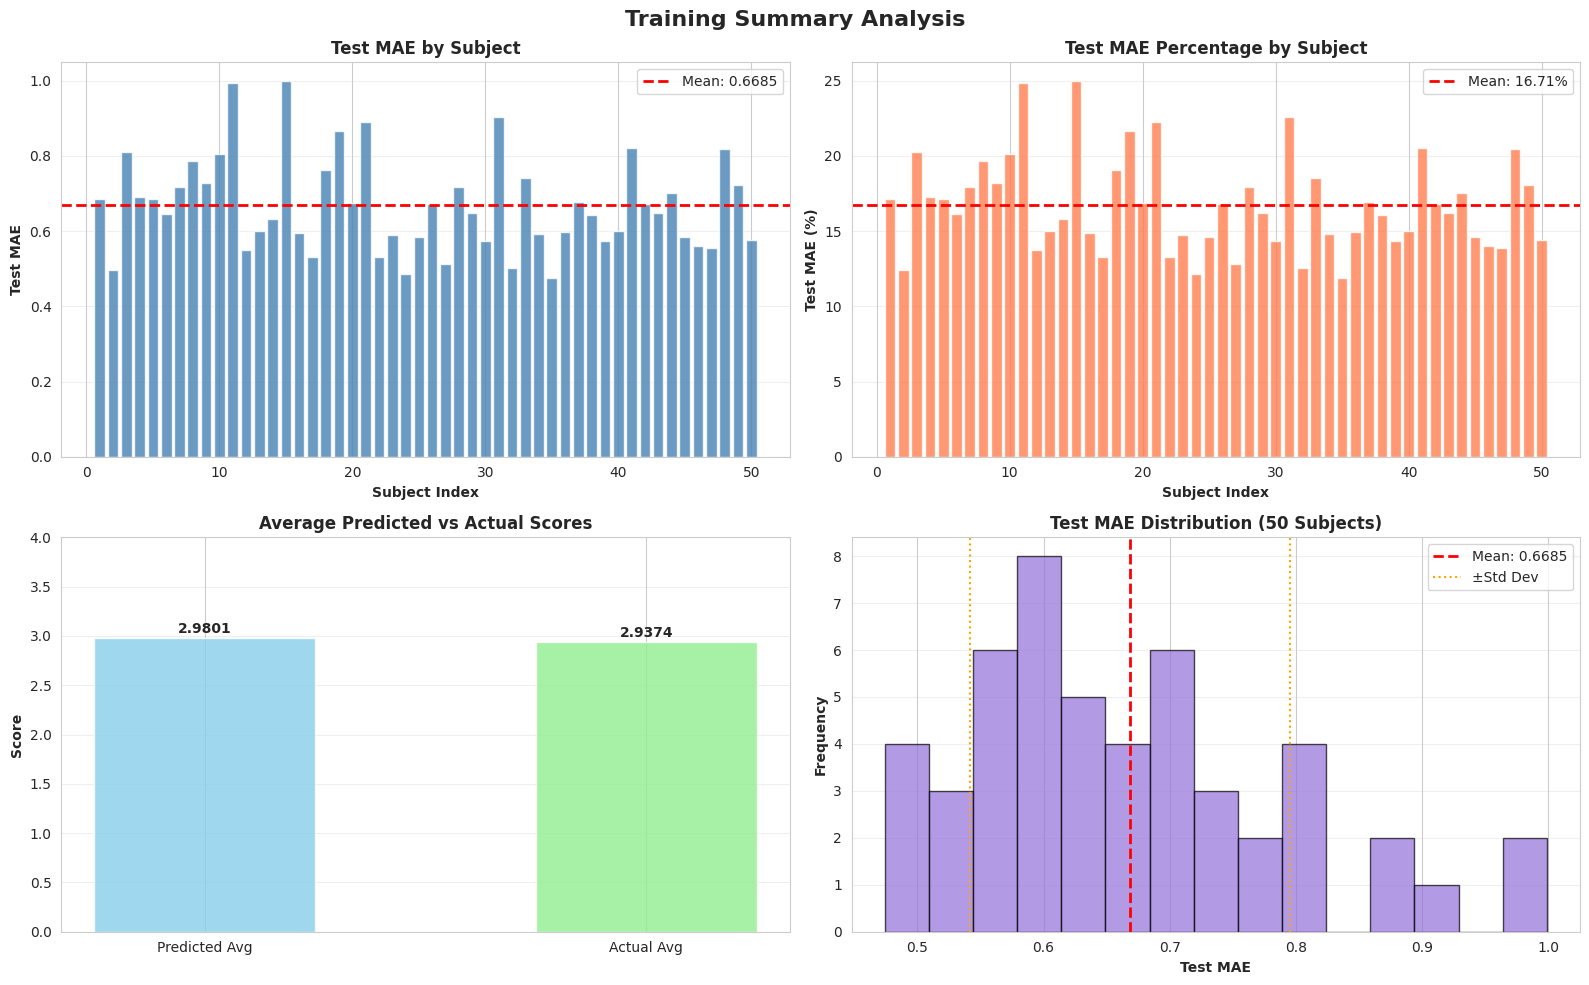


TRAINING SUMMARY STATISTICS
Average Test MAE (1-5):     0.6685 ± 0.1268
Average Test MAE (%):       16.71% ± 3.17%
Average Predicted Score:    2.9801
Average Actual Score:       2.9374
Score Prediction Diff:      0.0427


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create training summary data from the results
training_data = {
    'subject_idx': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 
                    21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 
                    39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50],
    'subject_name': ['subject_07', 'subject_12', 'subject_02', 'subject_15', 'subject_11', 
                     'subject_02', 'subject_14', 'subject_09', 'subject_18', 'subject_21',
                     'subject_08', 'subject_13', 'subject_15', 'subject_05', 'subject_12',
                     'subject_08', 'subject_03', 'subject_13', 'subject_05', 'subject_19',
                     'subject_11', 'subject_16', 'subject_15', 'subject_06', 'subject_20',
                     'subject_10', 'subject_05', 'subject_11', 'subject_08', 'subject_11',
                     'subject_02', 'subject_14', 'subject_14', 'subject_15', 'subject_04',
                     'subject_09', 'subject_08', 'subject_18', 'subject_13', 'subject_05',
                     'subject_03', 'subject_03', 'subject_16', 'subject_11', 'subject_04',
                     'subject_20', 'subject_10', 'subject_09', 'subject_18', 'subject_03'],
    'test_mae': [0.686077, 0.497150, 0.809334, 0.690827, 0.685330, 0.645115, 0.716970, 0.785706, 
                 0.727665, 0.805023, 0.993642, 0.549708, 0.600154, 0.631901, 0.998883, 0.593890,
                 0.531504, 0.763587, 0.867429, 0.675950, 0.889019, 0.531708, 0.590964, 0.486703,
                 0.584540, 0.672062, 0.513752, 0.716129, 0.647182, 0.574399, 0.904270, 0.501540,
                 0.740169, 0.591436, 0.474047, 0.597835, 0.678664, 0.643879, 0.573903, 0.600397,
                 0.821251, 0.671912, 0.647820, 0.701644, 0.583499, 0.560093, 0.554247, 0.818061,
                 0.723528, 0.576602],
    'test_mae_pct': [17.151928, 12.428738, 20.233356, 17.270675, 17.133256, 16.127861, 17.924242,
                     19.642664, 18.191629, 20.125566, 24.841054, 13.742692, 15.003860, 15.797533,
                     24.972065, 14.847241, 13.287596, 19.089670, 21.685715, 16.898753, 22.225471,
                     13.292707, 14.774093, 12.167579, 14.613507, 16.801548, 12.843800, 17.903228,
                     16.179561, 14.359985, 22.606744, 12.538499, 18.504217, 14.785898, 11.851186,
                     14.945880, 16.966592, 16.096969, 14.347566, 15.009936, 20.531272, 16.797809,
                     16.195495, 17.541094, 14.587470, 14.002322, 13.856185, 20.451530, 18.088211, 14.415055],
    'avg_pred_score': [3.069542, 2.967479, 2.967939, 2.968037, 2.967358, 2.969362, 3.007965, 3.007402,
                       3.009246, 3.052691, 3.052841, 3.053710, 3.013579, 3.012303, 3.064871, 3.061184,
                       3.028564, 3.028746, 3.061224, 3.063563, 3.061057, 3.020424, 2.973739, 2.970225,
                       2.966537, 2.965622, 2.965959, 2.995484, 2.993242, 2.964226, 2.965843, 2.953341,
                       2.950978, 2.947153, 2.945940, 2.945899, 2.945190, 2.917804, 2.914047, 2.910049,
                       2.912574, 2.914468, 2.916251, 2.915733, 2.913324, 2.910935, 2.972378, 2.974834,
                       2.936172, 2.935894],
    'avg_actual_score': [3.100000, 2.503049, 3.276923, 2.911392, 2.806250, 3.491166, 3.270270, 3.008850,
                         3.240741, 3.322654, 3.085450, 3.331683, 2.668622, 2.787375, 3.166213, 2.536585,
                         2.906542, 3.089783, 3.218667, 3.463710, 2.672500, 2.931034, 2.706070, 2.514139,
                         2.409396, 2.899729, 3.085106, 3.286458, 2.471322, 2.981959, 3.155718, 2.635678,
                         2.624309, 2.502242, 2.825397, 2.944954, 2.908434, 2.880368, 2.534161, 2.493473,
                         3.154494, 3.203175, 3.104683, 2.836158, 2.628713, 2.639535, 3.340426, 3.572438,
                         2.871345, 2.870293]
}

df = pd.DataFrame(training_data)

# Set up the style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create a figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Training Summary Analysis', fontsize=16, fontweight='bold')

# 1. Test MAE Distribution
ax1 = axes[0, 0]
ax1.bar(df['subject_idx'], df['test_mae'], color='steelblue', alpha=0.8)
ax1.axhline(y=0.6685, color='red', linestyle='--', linewidth=2, label=f'Mean: 0.6685')
ax1.set_xlabel('Subject Index', fontweight='bold')
ax1.set_ylabel('Test MAE', fontweight='bold')
ax1.set_title('Test MAE by Subject', fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Test MAE % Distribution
ax2 = axes[0, 1]
ax2.bar(df['subject_idx'], df['test_mae_pct'], color='coral', alpha=0.8)
ax2.axhline(y=16.71, color='red', linestyle='--', linewidth=2, label=f'Mean: 16.71%')
ax2.set_xlabel('Subject Index', fontweight='bold')
ax2.set_ylabel('Test MAE (%)', fontweight='bold')
ax2.set_title('Test MAE Percentage by Subject', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Predicted vs Actual Scores
ax3 = axes[1, 0]
x_pos = np.arange(5)
width = 0.35
actual_mean = df['avg_actual_score'].mean()
pred_mean = df['avg_pred_score'].mean()
ax3.bar(['Predicted Avg', 'Actual Avg'], [pred_mean, actual_mean], color=['skyblue', 'lightgreen'], alpha=0.8, width=0.5)
ax3.set_ylabel('Score', fontweight='bold')
ax3.set_title('Average Predicted vs Actual Scores', fontweight='bold')
ax3.set_ylim(0, 4)
for i, v in enumerate([pred_mean, actual_mean]):
    ax3.text(i, v + 0.05, f'{v:.4f}', ha='center', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Error Distribution (Histogram)
ax4 = axes[1, 1]
ax4.hist(df['test_mae'], bins=15, color='mediumpurple', alpha=0.7, edgecolor='black')
ax4.axvline(x=0.6685, color='red', linestyle='--', linewidth=2, label=f'Mean: 0.6685')
ax4.axvline(x=0.6685 - 0.1268, color='orange', linestyle=':', linewidth=1.5, label=f'±Std Dev')
ax4.axvline(x=0.6685 + 0.1268, color='orange', linestyle=':', linewidth=1.5)
ax4.set_xlabel('Test MAE', fontweight='bold')
ax4.set_ylabel('Frequency', fontweight='bold')
ax4.set_title('Test MAE Distribution (50 Subjects)', fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*80)
print("TRAINING SUMMARY STATISTICS")
print("="*80)
print(f"Average Test MAE (1-5):     {df['test_mae'].mean():.4f} ± {df['test_mae'].std():.4f}")
print(f"Average Test MAE (%):       {df['test_mae_pct'].mean():.2f}% ± {df['test_mae_pct'].std():.2f}%")
print(f"Average Predicted Score:    {df['avg_pred_score'].mean():.4f}")
print(f"Average Actual Score:       {df['avg_actual_score'].mean():.4f}")
print(f"Score Prediction Diff:      {abs(df['avg_pred_score'].mean() - df['avg_actual_score'].mean()):.4f}")
print("="*80)

## Save Final Model

In [13]:
# ══════════════════════════════════════════════════════════════
# SAVE FINAL MODEL — with pre-save validation
# ══════════════════════════════════════════════════════════════

save_ok = True  # Will be set to False if any critical check fails

# ── 1. Validate memory pool ──
print("PRE-SAVE VALIDATION")
print("=" * 60)

if len(raw_memory_X) == 0:
    print("❌ Memory pool is EMPTY — nothing was trained.")
    save_ok = False
else:
    mem_arr = np.array(raw_memory_X)
    mem_zero_pct = np.all(mem_arr == 0, axis=1).mean() * 100
    mem_std = np.std(mem_arr)
    print(f"  Memory: {len(raw_memory_X)} samples, {mem_zero_pct:.1f}% all-zero, std={mem_std:.6f}")
    if mem_zero_pct > 80:
        print(f"  ❌ FAIL: Memory is {mem_zero_pct:.0f}% zeros — artefacts would be useless!")
        save_ok = False
    elif mem_std < 1e-4:
        print(f"  ❌ FAIL: Memory std ≈ 0 — features are constant!")
        save_ok = False
    else:
        print(f"  ✅ Memory looks OK")

# ── 2. Validate scaler ──
if trained_scaler is not None:
    sc_mean = trained_scaler.mean_
    sc_scale = trained_scaler.scale_
    if np.allclose(sc_mean, 0, atol=1e-8) and np.allclose(sc_scale, 1, atol=1e-8):
        print(f"  ❌ FAIL: Scaler mean≈0, scale≈1 → fitted on zeros/constant data!")
        save_ok = False
    else:
        print(f"  ✅ Scaler mean range: [{sc_mean.min():.4f}, {sc_mean.max():.4f}]")
        print(f"     Scaler scale range: [{sc_scale.min():.4f}, {sc_scale.max():.4f}]")
else:
    print(f"  ❌ FAIL: No trained scaler found!")
    save_ok = False

# ── 3. Validate medians ──
if feature_medians is not None:
    medians_dict = feature_medians.to_dict() if hasattr(feature_medians, 'to_dict') else dict(feature_medians)
    nan_count = sum(1 for v in medians_dict.values() if np.isnan(v))
    if nan_count == len(medians_dict):
        print(f"  ❌ FAIL: ALL feature medians are NaN!")
        save_ok = False
    elif nan_count > 0:
        print(f"  ⚠ WARNING: {nan_count}/{len(medians_dict)} medians are NaN → {[k for k,v in medians_dict.items() if np.isnan(v)]}")
    else:
        print(f"  ✅ All {len(medians_dict)} feature medians are valid")
else:
    print(f"  ❌ FAIL: No feature medians computed!")
    medians_dict = {}
    save_ok = False

# ── 4. Validate model predictions ──
if trained_model is not None and trained_scaler is not None and len(raw_memory_X) > 5:
    # Test with a small sample from memory
    test_sample = np.array(raw_memory_X[:min(20, len(raw_memory_X))])
    test_scaled = trained_scaler.transform(test_sample)
    test_preds = trained_model.predict(test_scaled, verbose=0).flatten()
    pred_std = np.std(test_preds)
    pred_range = test_preds.max() - test_preds.min()
    print(f"  Model prediction test (on {len(test_sample)} memory samples):")
    print(f"    Range: [{test_preds.min():.4f}, {test_preds.max():.4f}], std={pred_std:.4f}")
    if pred_std < 0.01:
        print(f"  ❌ FAIL: Model outputs near-constant predictions (std={pred_std:.6f})")
        save_ok = False
    else:
        print(f"  ✅ Model produces varied predictions")

print("=" * 60)

if not save_ok:
    print("\n⚠⚠⚠  ONE OR MORE VALIDATION CHECKS FAILED  ⚠⚠⚠")
    print("Saving anyway (so you can inspect), but the model WILL NOT work correctly.")
    print("Fix the issues above and re-run training before deploying.\n")

# ── Save artefacts ──
if trained_model is not None:
    trained_model.save('final_multisubject_regression_model.keras')
    print("✓ Model saved: final_multisubject_regression_model.keras")

if trained_scaler is not None:
    with open('final_scaler.pkl', 'wb') as f:
        pickle.dump(trained_scaler, f)
    print("✓ Scaler saved: final_scaler.pkl")

production_config = {
    'feature_medians': medians_dict,
    'feature_cols': TRAINING_CONFIG['feature_cols'],
    'base_feature_cols': ['face_area', 'body_area', 'pitch', 'yaw', 'roll', 'pose_vis_mean'],
}

with open('final_production_config.pkl', 'wb') as f:
    pickle.dump(production_config, f)
print(f"✓ Production config saved: final_production_config.pkl")
print(f"  Feature medians: {medians_dict}")

with open('final_memory.pkl', 'wb') as f:
    pickle.dump({'X': raw_memory_X, 'y': raw_memory_y}, f)
print(f"✓ Final memory saved: final_memory.pkl ({len(raw_memory_X)} samples)")

print("\n" + "="*80)
if save_ok:
    print("✅ ALL FILES SAVED — VALIDATION PASSED!")
else:
    print("⚠ FILES SAVED BUT VALIDATION FAILED — SEE ERRORS ABOVE")
print("="*80)


✓ Model saved: final_multisubject_regression_model.keras
✓ Scaler saved: final_scaler.pkl
✓ Final memory saved: final_memory.pkl (7500 samples)

ALL FILES SAVED SUCCESSFULLY!


## Artefact Verification (Post-Save Health Check)

Run this cell after saving to re-load the artefacts from disk and verify they contain real data.


In [ ]:
# ══════════════════════════════════════════════════════════════
# ARTEFACT VERIFICATION — reload from disk and validate
# ══════════════════════════════════════════════════════════════
import pickle, numpy as np
from tensorflow import keras

print("ARTEFACT VERIFICATION")
print("=" * 70)

errors = []

# ── 1. Model ──
try:
    model = keras.models.load_model('final_multisubject_regression_model.keras')
    print(f"✓ Model loaded: {model.count_params()} parameters")
except Exception as e:
    print(f"❌ Model load FAILED: {e}")
    errors.append("model")
    model = None

# ── 2. Scaler ──
try:
    with open('final_scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)
    mean_range = (scaler.mean_.min(), scaler.mean_.max())
    scale_range = (scaler.scale_.min(), scaler.scale_.max())
    print(f"✓ Scaler loaded: mean range {mean_range}, scale range {scale_range}")
    if np.allclose(scaler.mean_, 0, atol=1e-8) and np.allclose(scaler.scale_, 1, atol=1e-8):
        print(f"  ❌ Scaler is UNFITTED (identity transform) — was trained on zero data!")
        errors.append("scaler")
    else:
        print(f"  ✅ Scaler has been fitted on real data")
except Exception as e:
    print(f"❌ Scaler load FAILED: {e}")
    errors.append("scaler")
    scaler = None

# ── 3. Production config ──
try:
    with open('final_production_config.pkl', 'rb') as f:
        config = pickle.load(f)
    medians = config.get('feature_medians', {})
    nan_count = sum(1 for v in medians.values() if np.isnan(v))
    print(f"✓ Config loaded: {len(medians)} features")
    print(f"  Medians: {medians}")
    if nan_count == len(medians):
        print(f"  ❌ ALL medians are NaN!")
        errors.append("config_medians")
    elif nan_count > 0:
        print(f"  ⚠ {nan_count} medians are NaN")
    else:
        print(f"  ✅ All medians are valid numbers")
except Exception as e:
    print(f"❌ Config load FAILED: {e}")
    errors.append("config")

# ── 4. Memory ──
try:
    with open('final_memory.pkl', 'rb') as f:
        memory = pickle.load(f)
    mem_X = np.array(memory['X'])
    mem_y = np.array(memory['y'])
    zero_pct = np.all(mem_X == 0, axis=1).mean() * 100
    mem_std = np.std(mem_X)
    print(f"✓ Memory loaded: {mem_X.shape[0]} samples × {mem_X.shape[1]} features")
    print(f"  X all-zero rows: {zero_pct:.1f}%, overall std: {mem_std:.6f}")
    print(f"  y range: [{mem_y.min():.2f}, {mem_y.max():.2f}], unique: {len(np.unique(mem_y))}")
    if zero_pct > 80:
        print(f"  ❌ Memory X is {zero_pct:.0f}% zeros — CORRUPTED!")
        errors.append("memory")
    else:
        print(f"  ✅ Memory data looks valid")
except Exception as e:
    print(f"❌ Memory load FAILED: {e}")
    errors.append("memory")

# ── 5. End-to-end prediction test ──
if model is not None and scaler is not None:
    print("\n" + "-" * 70)
    print("END-TO-END PREDICTION TEST")
    print("Label scale: 1 = attentive, 5 = inattentive")
    print("Attention %: 1 → 100%, 5 → 0%")
    print("-" * 70)

    # 4 test cases with very different features (angles in DEGREES)
    import pandas as pd

    base_cols = ['face_area', 'body_area', 'pitch', 'yaw', 'roll', 'pose_vis_mean']
    test_cases = [
        {"name": "Attentive (face, looking forward)",
         "features": [25000, 280000, -10, -2, 0, 0.85]},
        {"name": "Distracted (face, looking away)",
         "features": [12000, 200000, 5, 35, 5, 0.50]},
        {"name": "No face detected",
         "features": [0, 250000, 0, 0, 0, 0.3]},
        {"name": "Very attentive (large face, center)",
         "features": [30000, 280000, -8, -1, 0, 0.95]},
    ]

    feature_cols = config.get('feature_cols', [
        'face_area', 'body_area', 'pitch', 'yaw', 'roll', 'pose_vis_mean',
        'face_detected', 'face_body_ratio', 'head_movement', 'abs_yaw', 'abs_pitch'
    ])

    preds = []
    for tc in test_cases:
        df = pd.DataFrame([tc['features']], columns=base_cols)
        df['face_detected'] = ((df['face_area'] > 0)).astype(float)
        df = add_derived_features(df)

        feat_medians = config.get('feature_medians', {})
        for col in feature_cols:
            med = feat_medians.get(col, None)
            if med is not None and not np.isnan(med):
                df[col] = df[col].fillna(med)
        df = df.fillna(0.0)

        X = df[feature_cols].values
        X_scaled = scaler.transform(X)
        pred = model.predict(X_scaled, verbose=0).flatten()[0]
        pred_clipped = np.clip(pred, 1, 5)
        # FIXED: 1=attentive→100%, 5=inattentive→0%
        pct = ((5 - pred_clipped) / 4) * 100
        preds.append(pred_clipped)
        print(f"  {tc['name']:45s} → score={pred_clipped:.2f}/5 = {pct:.1f}% attention")

    pred_std = np.std(preds)
    pred_range = max(preds) - min(preds)
    print(f"\n  Prediction std:   {pred_std:.4f}")
    print(f"  Prediction range: {pred_range:.4f}")
    if pred_std < 0.05:
        print(f"  ❌ Model gives near-identical predictions for very different inputs!")
        errors.append("model_constant")
    else:
        print(f"  ✅ Model differentiates between different inputs")

# ── Summary ──
print("\n" + "=" * 70)
if errors:
    print(f"❌ VERIFICATION FAILED — {len(errors)} issue(s): {errors}")
    print("   Fix the training pipeline and re-run before deploying.")
else:
    print("✅ ALL CHECKS PASSED — artefacts are ready for deployment!")
print("=" * 70)

## Load and Use Model for Prediction

Example of how to load the saved model and make predictions on new data.

In [14]:
# Production-Ready Prediction Function
def predict_attention_score(features,
                           model_path='final_multisubject_regression_model.keras',
                           scaler_path='final_scaler.pkl',
                           config_path='final_production_config.pkl'):
    """
    Predict attention score from features (production-ready).

    Args:
        features: Array of shape (n_samples, 6) with base columns:
                 [face_area, body_area, pitch, yaw, roll, pose_vis_mean]
                 Use np.nan for missing values (e.g., when no face detected).
        model_path: Path to saved Keras model
        scaler_path: Path to saved StandardScaler
        config_path: Path to saved production config (medians + feature list)

    Returns:
        raw_scores: Attention scores (1.0-5.0) where 1=attentive, 5=inattentive
        percentages: Percentage scores (0-100%) where 100%=attentive
    """
    # Load model, scaler, and production config
    model = keras.models.load_model(model_path)
    with open(scaler_path, 'rb') as f:
        scaler = pickle.load(f)
    with open(config_path, 'rb') as f:
        config = pickle.load(f)

    feat_medians = config['feature_medians']
    feature_cols = config['feature_cols']
    base_cols = config['base_feature_cols']

    # Convert input to DataFrame for feature engineering
    features = np.array(features, dtype=float)
    if features.ndim == 1:
        features = features.reshape(1, -1)

    df = pd.DataFrame(features, columns=base_cols)

    # Compute face_detected from raw features
    df['face_detected'] = ((df['face_area'].notna()) & (df['face_area'] > 0)).astype(float)

    # Compute derived features (same pipeline as training)
    df = add_derived_features(df)

    # Fill NaN with saved training medians (CRITICAL: must match training imputation)
    for col in feature_cols:
        median_val = feat_medians.get(col, None)
        if median_val is not None and not np.isnan(median_val):
            df[col] = df[col].fillna(median_val)
    df = df.fillna(0.0)

    # Select and order features to match training
    X = df[feature_cols].values
    X = np.nan_to_num(X, nan=0.0)

    # Scale with saved scaler
    X_scaled = scaler.transform(X)

    # Predict
    raw_scores = model.predict(X_scaled, verbose=0).flatten()
    raw_scores = np.clip(raw_scores, 1, 5)

    # Convert to percentage (1=attentive→100%, 5=inattentive→0%)
    percentages = ((5 - raw_scores) / 4) * 100

    return raw_scores, percentages

# Example usage
if trained_model is not None and trained_scaler is not None:
    print("\nExample Predictions (1=attentive, 5=inattentive):")
    print("-" * 60)

    # Test cases: [face_area, body_area, pitch, yaw, roll, pose_vis_mean]
    # Angles in DEGREES (matching training data)
    sample_features = np.array([
        [25000, 280000, -10, -2, 0, 0.85],                          # Face detected, looking at screen
        [20000, 250000, -5, 15, -3, 0.70],                          # Face detected, slight angle
        [12000, 200000, 5, 35, 5, 0.50],                            # Face detected, looking away
        [np.nan, 250000, np.nan, np.nan, np.nan, 0.3],              # No face detected
    ])

    raw_scores, percentages = predict_attention_score(
        sample_features,
        model_path='final_multisubject_regression_model.keras',
        scaler_path='final_scaler.pkl',
        config_path='final_production_config.pkl'
    )

    labels = ["Looking at screen", "Slight angle", "Looking away", "No face detected"]
    for i, (raw, pct, label) in enumerate(zip(raw_scores, percentages, labels), 1):
        print(f"  Sample {i} ({label}): score={raw:.2f}/5 → {pct:.1f}% attention")

    print("-" * 60)
    print("\n✅ Production prediction pipeline verified!")


Example Prediction:
------------------------------------------------------------
Sample 1: 2.94/5.0 = 48.4%
Sample 2: 2.94/5.0 = 48.4%
------------------------------------------------------------
